In [16]:
# ============================================================
# SECTION 1: PROJECT OVERVIEW
# ============================================================

"""
Project:
Multi-Agent AI Framework for Fossil Fuel Displacement

Agent:
Renewable Generation Agent

Corrected Architecture:
1. Solar model uses high-frequency/hourly solar data.
2. Wind model uses daily All-India wind generation data.
3. Renewable Fusion Layer combines solar + wind predictions.
4. Coordinator Agent receives final renewable generation output.

Why hourly solar?
Daily solar aggregation gives only around 34 rows.
That is too small for GridSearchCV, TimeSeriesSplit, lag features, and forecasting.
Hourly solar keeps enough samples for proper ML training.

Solar Target:
DAILY_YIELD

Wind Target:
Wind_Generation
"""

'\nProject:\nMulti-Agent AI Framework for Fossil Fuel Displacement\n\nAgent:\nRenewable Generation Agent\n\nCorrected Architecture:\n1. Solar model uses high-frequency/hourly solar data.\n2. Wind model uses daily All-India wind generation data.\n3. Renewable Fusion Layer combines solar + wind predictions.\n4. Coordinator Agent receives final renewable generation output.\n\nWhy hourly solar?\nDaily solar aggregation gives only around 34 rows.\nThat is too small for GridSearchCV, TimeSeriesSplit, lag features, and forecasting.\nHourly solar keeps enough samples for proper ML training.\n\nSolar Target:\nDAILY_YIELD\n\nWind Target:\nWind_Generation\n'

In [17]:
# ============================================================
# SECTION 2: IMPORTS AND CONFIGURATION
# ============================================================

import os
import sys
import json
import time
import platform
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import sklearn
import xgboost

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    explained_variance_score
)
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

try:
    from fpdf import FPDF
    FPDF_AVAILABLE = True
except Exception:
    FPDF_AVAILABLE = False

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
N_SPLITS = 5

ENABLE_SHAP = True
ENABLE_LEARNING_CURVE = True

In [18]:
# ============================================================
# SECTION 3: DATASET PATHS
# ============================================================

BASE_DATASET_PATH = r"E:\Multi_agentic_AI_Project\Dataset"

SOLAR_FOLDER = os.path.join(BASE_DATASET_PATH, "Solar Power Generation Data")

possible_wind_folders = [
    os.path.join(BASE_DATASET_PATH, "wind_dataset"),
    os.path.join(BASE_DATASET_PATH, "wind_datset"),
    os.path.join(BASE_DATASET_PATH, "Wind Dataset"),
    os.path.join(BASE_DATASET_PATH, "WIND_DATASET")
]

WIND_FOLDER = None

for folder in possible_wind_folders:
    if os.path.exists(folder):
        WIND_FOLDER = folder
        break

if WIND_FOLDER is None:
    raise FileNotFoundError(
        "Wind folder not found. Checked:\n" +
        "\n".join(possible_wind_folders)
    )

SOLAR_FILES = {
    "plant_1_generation": os.path.join(SOLAR_FOLDER, "Plant_1_Generation_Data.csv"),
    "plant_1_weather": os.path.join(SOLAR_FOLDER, "Plant_1_Weather_Sensor_Data.csv"),
    "plant_2_generation": os.path.join(SOLAR_FOLDER, "Plant_2_Generation_Data.csv"),
    "plant_2_weather": os.path.join(SOLAR_FOLDER, "Plant_2_Weather_Sensor_Data.csv")
}

WIND_SOURCE_FILE = os.path.join(WIND_FOLDER, "Daily_Power_Gen_Source_march_23.csv")
WIND_STATES_FILE = os.path.join(WIND_FOLDER, "Daily_Power_Gen_States_march_23.csv")

for name, path in SOLAR_FILES.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing solar file: {path}")

if not os.path.exists(WIND_SOURCE_FILE):
    raise FileNotFoundError(f"Missing wind source file: {WIND_SOURCE_FILE}")

print("Base Dataset Path:", BASE_DATASET_PATH)
print("Solar Folder:", SOLAR_FOLDER)
print("Wind Folder Used:", WIND_FOLDER)
print("Wind Files:", os.listdir(WIND_FOLDER))

Base Dataset Path: E:\Multi_agentic_AI_Project\Dataset
Solar Folder: E:\Multi_agentic_AI_Project\Dataset\Solar Power Generation Data
Wind Folder Used: E:\Multi_agentic_AI_Project\Dataset\wind_datset
Wind Files: ['Daily_Power_Gen_Source_march_23.csv', 'Daily_Power_Gen_States_march_23.csv']


In [19]:
# ============================================================
# SECTION 4: UTILITY FUNCTIONS
# ============================================================

def save_json(data, file_name):
    with open(file_name, "w") as file:
        json.dump(data, file, indent=4)


def parse_datetime_column(series):
    parsed = pd.to_datetime(series, errors="coerce", dayfirst=False)

    if parsed.isnull().mean() > 0.20:
        parsed = pd.to_datetime(series, errors="coerce", dayfirst=True)

    return parsed


def calculate_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": calculate_mape(y_true, y_pred),
        "Median_AE": median_absolute_error(y_true, y_pred),
        "Explained_Variance": explained_variance_score(y_true, y_pred)
    }


def fit_status(train_r2, test_r2):
    gap = train_r2 - test_r2

    if test_r2 < 0.50:
        return "Underfitting"
    elif gap <= 0.05:
        return "Good Fit"
    elif gap <= 0.10:
        return "Slight Overfitting"
    else:
        return "Severe Overfitting"


def confidence_from_row(row):
    score = row.get("CV_Mean_R2", row.get("R2", 0))

    if pd.isna(score):
        score = row.get("R2", 0)

    return float(max(0.0, min(1.0, score)))


def create_timeseries_cv(train_size):
    if train_size >= 250:
        splits = 5
    elif train_size >= 100:
        splits = 4
    elif train_size >= 40:
        splits = 3
    else:
        splits = 2

    print("=" * 60)
    print("Training Samples:", train_size)
    print("Using TimeSeriesSplit:", splits)
    print("=" * 60)

    return TimeSeriesSplit(n_splits=splits)


class WeightedEnsembleRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, estimators=None, weights=None):
        self.estimators = estimators
        self.weights = weights

    def fit(self, X, y):
        self.fitted_estimators_ = []

        for name, estimator in self.estimators:
            model = clone(estimator)
            model.fit(X, y)
            self.fitted_estimators_.append((name, model))

        return self

    def predict(self, X):
        predictions = []

        for name, model in self.fitted_estimators_:
            predictions.append(model.predict(X))

        predictions = np.array(predictions)
        weights = np.array(self.weights)

        return np.average(predictions, axis=0, weights=weights)


def add_time_features(dataframe, date_col):
    dataframe["Year"] = dataframe[date_col].dt.year
    dataframe["Month"] = dataframe[date_col].dt.month
    dataframe["Quarter"] = dataframe[date_col].dt.quarter
    dataframe["Week"] = dataframe[date_col].dt.isocalendar().week.astype(int)
    dataframe["Day"] = dataframe[date_col].dt.day
    dataframe["Hour"] = dataframe[date_col].dt.hour
    dataframe["Day_of_Week"] = dataframe[date_col].dt.dayofweek
    dataframe["Day_of_Year"] = dataframe[date_col].dt.dayofyear
    dataframe["Is_Weekend"] = dataframe["Day_of_Week"].isin([5, 6]).astype(int)

    dataframe["MonthSin"] = np.sin(2 * np.pi * dataframe["Month"] / 12)
    dataframe["MonthCos"] = np.cos(2 * np.pi * dataframe["Month"] / 12)
    dataframe["WeekSin"] = np.sin(2 * np.pi * dataframe["Week"] / 52)
    dataframe["WeekCos"] = np.cos(2 * np.pi * dataframe["Week"] / 52)
    dataframe["HourSin"] = np.sin(2 * np.pi * dataframe["Hour"] / 24)
    dataframe["HourCos"] = np.cos(2 * np.pi * dataframe["Hour"] / 24)

    return dataframe


def add_lag_rolling_features(dataframe, target_col):
    n = len(dataframe)

    if n >= 365:
        lags = [1, 7, 30]
        windows = [7, 30]
    elif n >= 100:
        lags = [1, 3, 7]
        windows = [3, 7]
    elif n >= 30:
        lags = [1, 2, 3]
        windows = [2, 3]
    else:
        lags = [1]
        windows = [2]

    print("Rows:", n)
    print("Using Lags:", lags)
    print("Using Windows:", windows)

    for lag in lags:
        dataframe[f"Lag_{lag}"] = dataframe[target_col].shift(lag)

    for window in windows:
        dataframe[f"RollingMean_{window}"] = dataframe[target_col].shift(1).rolling(window).mean()
        dataframe[f"RollingStd_{window}"] = dataframe[target_col].shift(1).rolling(window).std()

    dataframe["Target_Diff"] = dataframe[target_col].diff()
    dataframe["Target_Growth"] = dataframe[target_col].pct_change()

    dataframe.replace([np.inf, -np.inf], np.nan, inplace=True)

    dataframe = dataframe.bfill()
    dataframe = dataframe.ffill()

    return dataframe

In [20]:
# ============================================================
# SECTION 5: LOAD SOLAR DATASETS AT HOURLY RESOLUTION
# ============================================================

def load_solar_plant_hourly(generation_path, weather_path, plant_name):
    gen_df = pd.read_csv(generation_path)
    weather_df = pd.read_csv(weather_path)

    gen_df.columns = gen_df.columns.str.strip()
    weather_df.columns = weather_df.columns.str.strip()

    gen_df["DATE_TIME"] = parse_datetime_column(gen_df["DATE_TIME"])
    weather_df["DATE_TIME"] = parse_datetime_column(weather_df["DATE_TIME"])

    for col in ["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]:
        gen_df[col] = pd.to_numeric(gen_df[col], errors="coerce")

    for col in ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]:
        weather_df[col] = pd.to_numeric(weather_df[col], errors="coerce")

    gen_df = gen_df.dropna(subset=["DATE_TIME"])
    weather_df = weather_df.dropna(subset=["DATE_TIME"])

    gen_df["DATE_HOUR"] = gen_df["DATE_TIME"].dt.floor("H")
    weather_df["DATE_HOUR"] = weather_df["DATE_TIME"].dt.floor("H")

    gen_hourly = gen_df.groupby("DATE_HOUR", as_index=False).agg({
        "DC_POWER": "sum",
        "AC_POWER": "sum",
        "DAILY_YIELD": "sum",
        "TOTAL_YIELD": "sum"
    })

    weather_hourly = weather_df.groupby("DATE_HOUR", as_index=False).agg({
        "AMBIENT_TEMPERATURE": "mean",
        "MODULE_TEMPERATURE": "mean",
        "IRRADIATION": "sum"
    })

    plant_hourly = pd.merge(
        gen_hourly,
        weather_hourly,
        on="DATE_HOUR",
        how="inner"
    )

    plant_hourly["Plant"] = plant_name

    return plant_hourly


solar_p1 = load_solar_plant_hourly(
    SOLAR_FILES["plant_1_generation"],
    SOLAR_FILES["plant_1_weather"],
    "Plant_1"
)

solar_p2 = load_solar_plant_hourly(
    SOLAR_FILES["plant_2_generation"],
    SOLAR_FILES["plant_2_weather"],
    "Plant_2"
)

solar_hourly = pd.concat([solar_p1, solar_p2], ignore_index=True)

solar_hourly = solar_hourly.groupby("DATE_HOUR", as_index=False).agg({
    "DC_POWER": "sum",
    "AC_POWER": "sum",
    "DAILY_YIELD": "sum",
    "TOTAL_YIELD": "sum",
    "AMBIENT_TEMPERATURE": "mean",
    "MODULE_TEMPERATURE": "mean",
    "IRRADIATION": "sum"
})

solar_hourly.rename(columns={"DATE_HOUR": "Date"}, inplace=True)

solar_hourly = solar_hourly.sort_values("Date").reset_index(drop=True)

solar_hourly.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in ["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]:
    solar_hourly[col] = pd.to_numeric(solar_hourly[col], errors="coerce")
    solar_hourly[col] = solar_hourly[col].interpolate(method="linear")
    solar_hourly[col] = solar_hourly[col].fillna(solar_hourly[col].median())

solar_hourly = solar_hourly[solar_hourly["DAILY_YIELD"] >= 0].copy()

solar_target = "DAILY_YIELD"

print("Solar Hourly Shape:", solar_hourly.shape)
display(solar_hourly.head())

Solar Hourly Shape: (816, 8)


,Date,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,134102.938095,5.733271e+10,25.889876,23.612870,0.0
1,2020-05-15 01:00:00,0.0,0.0,83444.000000,5.734707e+10,25.586619,23.792034,0.0
2,2020-05-15 02:00:00,0.0,0.0,75904.000000,5.733271e+10,25.641700,24.033793,0.0
3,2020-05-15 03:00:00,0.0,0.0,75537.666667,5.733271e+10,25.548140,24.377044,0.0
4,2020-05-15 04:00:00,0.0,0.0,53924.000000,5.735425e+10,24.893071,23.395668,0.0


In [21]:
# ============================================================
# SECTION 6: LOAD WIND DATASET
# ============================================================

wind_source_df = pd.read_csv(WIND_SOURCE_FILE)
wind_source_df.columns = wind_source_df.columns.str.strip()

wind_source_df["date"] = pd.to_datetime(wind_source_df["date"], errors="coerce")

for col in ["NR", "WR", "SR", "ER", "NER", "All India"]:
    wind_source_df[col] = pd.to_numeric(wind_source_df[col], errors="coerce")

wind_df = wind_source_df[
    wind_source_df["source"].astype(str).str.strip().str.lower() == "wind gen(mu)"
].copy()

wind_df = wind_df.dropna(subset=["date", "All India"])
wind_df = wind_df.sort_values("date").reset_index(drop=True)

wind_df.rename(
    columns={
        "date": "Date",
        "All India": "Wind_Generation"
    },
    inplace=True
)

for col in ["NR", "WR", "SR", "ER", "NER", "Wind_Generation"]:
    wind_df[col] = wind_df[col].interpolate(method="linear")
    wind_df[col] = wind_df[col].fillna(wind_df[col].median())

wind_df = wind_df[wind_df["Wind_Generation"] >= 0].copy()

wind_target = "Wind_Generation"

print("Wind Shape:", wind_df.shape)
display(wind_df.head())

if os.path.exists(WIND_STATES_FILE):
    wind_states_df = pd.read_csv(WIND_STATES_FILE)
    wind_states_df.columns = wind_states_df.columns.str.strip()
    print("Wind State Dataset Loaded:", wind_states_df.shape)
    display(wind_states_df.head())
else:
    wind_states_df = pd.DataFrame()

Wind Shape: (1573, 8)


,source,NR,WR,SR,ER,NER,Wind_Generation,Date
0,Wind Gen(MU),2.0,19.0,13.0,0.0,0.0,34,2013-03-31
1,Wind Gen(MU),7.0,21.0,19.0,0.0,0.0,48,2013-04-01
2,Wind Gen(MU),8.0,25.0,15.0,0.0,0.0,48,2013-04-02
3,Wind Gen(MU),3.0,22.0,6.0,0.0,0.0,31,2013-04-03
4,Wind Gen(MU),3.0,23.0,15.0,0.0,0.0,42,2013-04-04


Wind State Dataset Loaded: (126699, 6)


,Region,States,Max.Demand Met during the day(MW),Shortage during maximum Demand(MW),Energy Met (MU),date
0,NER,Mizoram,77,1.0,1.2,2015-01-01
1,WR,DD,214,0.0,4.8,2015-01-01
2,WR,Goa,383,0.0,7.3,2015-01-01
3,WR,Maharashtra,14837,57.0,315.0,2015-01-01
4,WR,MP,5740,0.0,109.8,2015-01-01


In [22]:
# ============================================================
# SECTION 7: DATA QUALITY REPORT
# ============================================================

renewable_data_quality_report = pd.DataFrame({
    "Dataset": ["Solar Hourly", "Wind Daily"],
    "Rows": [solar_hourly.shape[0], wind_df.shape[0]],
    "Columns": [solar_hourly.shape[1], wind_df.shape[1]],
    "Missing_Values": [solar_hourly.isnull().sum().sum(), wind_df.isnull().sum().sum()],
    "Duplicate_Rows": [solar_hourly.duplicated().sum(), wind_df.duplicated().sum()],
    "Target": [solar_target, wind_target]
})

display(renewable_data_quality_report)

renewable_data_quality_report.to_csv("renewable_data_quality_report.csv", index=False)

,Dataset,Rows,Columns,Missing_Values,Duplicate_Rows,Target
0,Solar Hourly,816,8,0,0,DAILY_YIELD
1,Wind Daily,1573,8,0,0,Wind_Generation


In [23]:
# ============================================================
# SECTION 8: OUTLIER REPORT
# ============================================================

def create_outlier_report(dataframe, numeric_cols, dataset_name):
    rows = []

    for col in numeric_cols:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        iqr_outliers = dataframe[
            (dataframe[col] < lower) |
            (dataframe[col] > upper)
        ].shape[0]

        if dataframe[col].std() != 0:
            z_scores = np.abs((dataframe[col] - dataframe[col].mean()) / dataframe[col].std())
            z_outliers = int((z_scores > 3).sum())
        else:
            z_outliers = 0

        rows.append({
            "Dataset": dataset_name,
            "Column": col,
            "IQR_Outliers": int(iqr_outliers),
            "ZScore_Outliers": z_outliers,
            "Lower_Bound": lower,
            "Upper_Bound": upper
        })

    return pd.DataFrame(rows)


solar_outlier_report = create_outlier_report(
    solar_hourly,
    ["DAILY_YIELD", "AC_POWER", "DC_POWER", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"],
    "Solar"
)

wind_outlier_report = create_outlier_report(
    wind_df,
    ["NR", "WR", "SR", "ER", "NER", "Wind_Generation"],
    "Wind"
)

renewable_outlier_report = pd.concat(
    [solar_outlier_report, wind_outlier_report],
    ignore_index=True
)

renewable_outlier_report.to_csv("renewable_outlier_report.csv", index=False)

display(renewable_outlier_report)

,Dataset,Column,IQR_Outliers,ZScore_Outliers,Lower_Bound,Upper_Bound
0,Solar,DAILY_YIELD,0,0,-1.155621e+06,2.192858e+06
1,Solar,AC_POWER,0,0,-1.517674e+05,2.529457e+05
2,Solar,DC_POWER,0,0,-8.992230e+05,1.498705e+06
3,Solar,AMBIENT_TEMPERATURE,0,0,1.534066e+01,3.776271e+01
4,Solar,MODULE_TEMPERATURE,0,0,-5.350202e+00,6.889384e+01
5,Solar,IRRADIATION,0,0,-5.553332e+00,9.255553e+00
6,Wind,NR,83,27,-1.000000e+01,3.000000e+01
7,Wind,WR,79,31,-3.250000e+01,9.950000e+01
8,Wind,SR,16,15,-8.500000e+01,1.790000e+02
9,Wind,ER,0,0,0.000000e+00,0.000000e+00


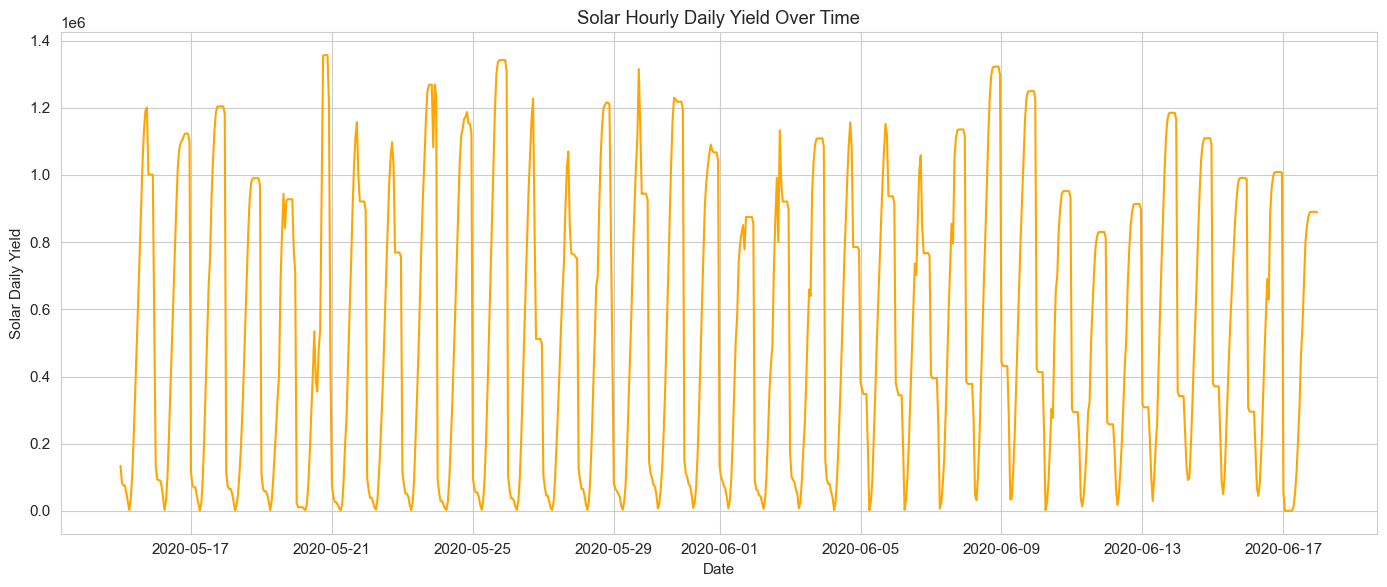

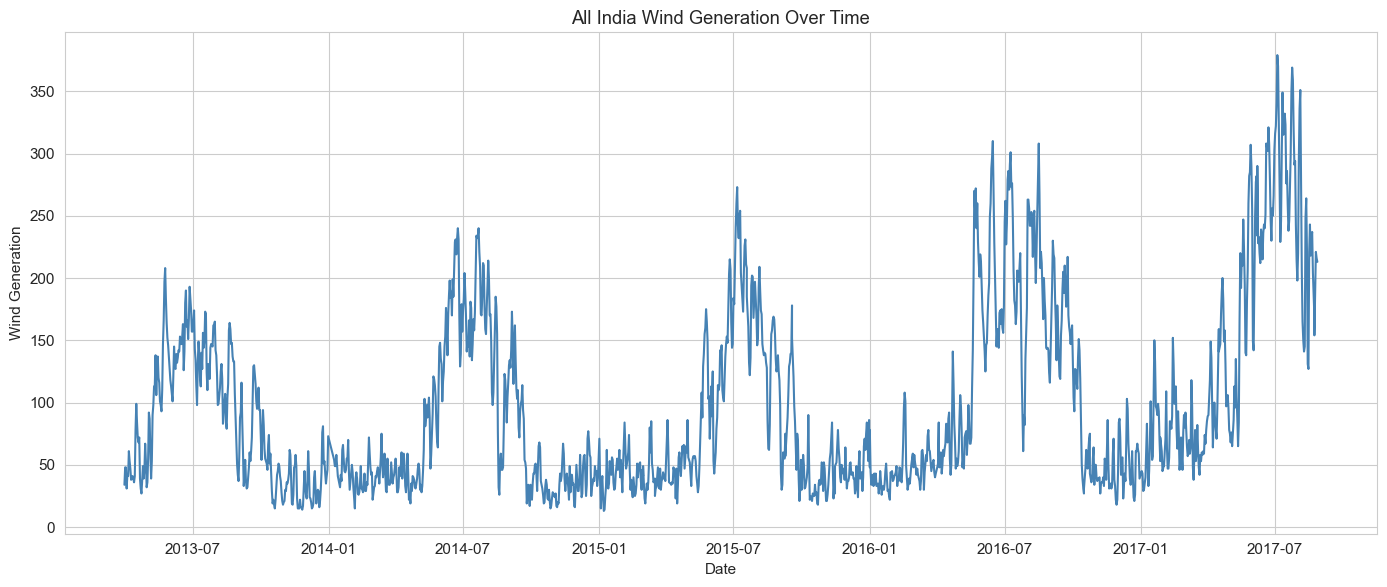

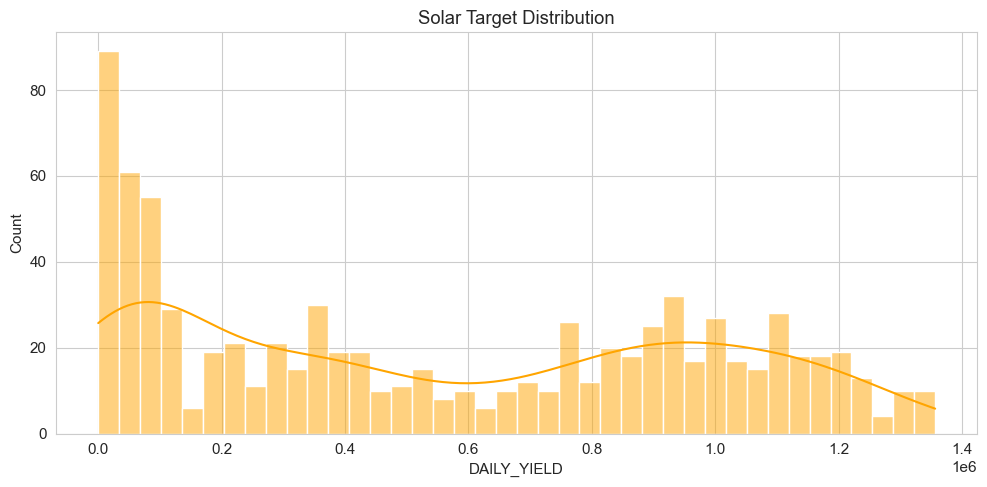

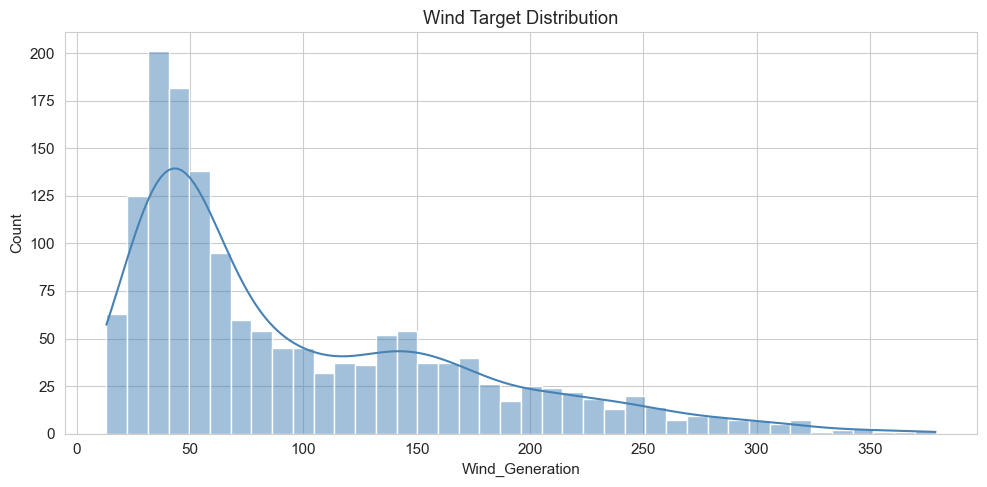

In [24]:
# ============================================================
# SECTION 9: EDA
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(solar_hourly["Date"], solar_hourly[solar_target], color="orange")
plt.title("Solar Hourly Daily Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Solar Daily Yield")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(wind_df["Date"], wind_df[wind_target], color="steelblue")
plt.title("All India Wind Generation Over Time")
plt.xlabel("Date")
plt.ylabel("Wind Generation")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(solar_hourly[solar_target], bins=40, kde=True, color="orange")
plt.title("Solar Target Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(wind_df[wind_target], bins=40, kde=True, color="steelblue")
plt.title("Wind Target Distribution")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# SECTION 10: FEATURE ENGINEERING
# ============================================================

solar_model_df = solar_hourly.copy()
solar_model_df = add_time_features(solar_model_df, "Date")
solar_model_df = add_lag_rolling_features(solar_model_df, solar_target)

solar_model_df["Irradiation_Squared"] = solar_model_df["IRRADIATION"] ** 2
solar_model_df["Temp_Difference"] = solar_model_df["MODULE_TEMPERATURE"] - solar_model_df["AMBIENT_TEMPERATURE"]
solar_model_df["Irradiation_Temp_Interaction"] = solar_model_df["IRRADIATION"] * solar_model_df["MODULE_TEMPERATURE"]
solar_model_df["AC_DC_Ratio"] = solar_model_df["AC_POWER"] / (solar_model_df["DC_POWER"] + 1e-6)

solar_model_df = solar_model_df.replace([np.inf, -np.inf], np.nan)
solar_model_df = solar_model_df.bfill()
solar_model_df = solar_model_df.ffill()
solar_model_df = solar_model_df.reset_index(drop=True)

wind_model_df = wind_df.copy()
wind_model_df = add_time_features(wind_model_df, "Date")
wind_model_df = add_lag_rolling_features(wind_model_df, wind_target)

wind_model_df["Regional_Total"] = wind_model_df[["NR", "WR", "SR", "ER", "NER"]].sum(axis=1)
wind_model_df["Regional_Mean"] = wind_model_df[["NR", "WR", "SR", "ER", "NER"]].mean(axis=1)
wind_model_df["Regional_Std"] = wind_model_df[["NR", "WR", "SR", "ER", "NER"]].std(axis=1)

wind_model_df = wind_model_df.replace([np.inf, -np.inf], np.nan)
wind_model_df = wind_model_df.bfill()
wind_model_df = wind_model_df.ffill()
wind_model_df = wind_model_df.reset_index(drop=True)

print("Solar Model Shape:", solar_model_df.shape)
print("Wind Model Shape:", wind_model_df.shape)

display(solar_model_df.head())
display(wind_model_df.head())

Rows: 816
Using Lags: [1, 7, 30]
Using Windows: [7, 30]
Rows: 1573
Using Lags: [1, 7, 30]
Using Windows: [7, 30]
Solar Model Shape: (816, 36)
Wind Model Shape: (1573, 35)


,Date,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,Year,Month,...,RollingMean_7,RollingStd_7,RollingMean_30,RollingStd_30,Target_Diff,Target_Growth,Irradiation_Squared,Temp_Difference,Irradiation_Temp_Interaction,AC_DC_Ratio
0,2020-05-15 00:00:00,0.0,0.0,134102.938095,5.733271e+10,25.889876,23.612870,0.0,2020,5,...,64772.678571,42305.487651,452406.882341,442266.580077,-50658.938095,-0.377762,0.0,-2.277006,0.0,0.0
1,2020-05-15 01:00:00,0.0,0.0,83444.000000,5.734707e+10,25.586619,23.792034,0.0,2020,5,...,64772.678571,42305.487651,452406.882341,442266.580077,-50658.938095,-0.377762,0.0,-1.794585,0.0,0.0
2,2020-05-15 02:00:00,0.0,0.0,75904.000000,5.733271e+10,25.641700,24.033793,0.0,2020,5,...,64772.678571,42305.487651,452406.882341,442266.580077,-7540.000000,-0.090360,0.0,-1.607907,0.0,0.0
3,2020-05-15 03:00:00,0.0,0.0,75537.666667,5.733271e+10,25.548140,24.377044,0.0,2020,5,...,64772.678571,42305.487651,452406.882341,442266.580077,-366.333333,-0.004826,0.0,-1.171096,0.0,0.0
4,2020-05-15 04:00:00,0.0,0.0,53924.000000,5.735425e+10,24.893071,23.395668,0.0,2020,5,...,64772.678571,42305.487651,452406.882341,442266.580077,-21613.666667,-0.286131,0.0,-1.497403,0.0,0.0


,source,NR,WR,SR,ER,NER,Wind_Generation,Date,Year,Month,...,Lag_30,RollingMean_7,RollingStd_7,RollingMean_30,RollingStd_30,Target_Diff,Target_Growth,Regional_Total,Regional_Mean,Regional_Std
0,Wind Gen(MU),2.0,19.0,13.0,0.0,0.0,34,2013-03-31,2013,3,...,34.0,43.571429,10.014276,50.033333,17.495779,14.0,0.411765,34.0,6.8,8.700575
1,Wind Gen(MU),7.0,21.0,19.0,0.0,0.0,48,2013-04-01,2013,4,...,34.0,43.571429,10.014276,50.033333,17.495779,14.0,0.411765,47.0,9.4,10.114346
2,Wind Gen(MU),8.0,25.0,15.0,0.0,0.0,48,2013-04-02,2013,4,...,34.0,43.571429,10.014276,50.033333,17.495779,0.0,0.000000,48.0,9.6,10.644247
3,Wind Gen(MU),3.0,22.0,6.0,0.0,0.0,31,2013-04-03,2013,4,...,34.0,43.571429,10.014276,50.033333,17.495779,-17.0,-0.354167,31.0,6.2,9.176056
4,Wind Gen(MU),3.0,23.0,15.0,0.0,0.0,42,2013-04-04,2013,4,...,34.0,43.571429,10.014276,50.033333,17.495779,11.0,0.354839,41.0,8.2,10.329569


In [26]:
# ============================================================
# SECTION 11: FEATURE SELECTION
# ============================================================

def select_features(dataframe, target_col, date_col, top_n=18):
    candidate_features = [
        col for col in dataframe.columns
        if col not in [date_col, target_col, "source"]
    ]

    X_all = dataframe[candidate_features].copy()
    y_all = dataframe[target_col].copy()

    mi_scores = mutual_info_regression(
        X_all,
        y_all,
        random_state=RANDOM_STATE
    )

    ranking = pd.DataFrame({
        "Feature": candidate_features,
        "Mutual_Information": mi_scores
    }).sort_values(by="Mutual_Information", ascending=False)

    selected = ranking.head(min(top_n, len(ranking)))["Feature"].tolist()

    return selected, ranking


solar_features, solar_feature_ranking = select_features(
    solar_model_df,
    solar_target,
    "Date",
    top_n=18
)

wind_features, wind_feature_ranking = select_features(
    wind_model_df,
    wind_target,
    "Date",
    top_n=18
)

selected_features_df = pd.concat([
    pd.DataFrame({"Dataset": "Solar", "Feature": solar_features}),
    pd.DataFrame({"Dataset": "Wind", "Feature": wind_features})
], ignore_index=True)

selected_features_df.to_csv("selected_features.csv", index=False)
solar_feature_ranking.to_csv("solar_feature_ranking.csv", index=False)
wind_feature_ranking.to_csv("wind_feature_ranking.csv", index=False)

print("Solar Features:", solar_features)
print("Wind Features:", wind_features)

Solar Features: ['Lag_1', 'Hour', 'Target_Growth', 'HourSin', 'Day_of_Year', 'Day', 'Lag_30', 'RollingMean_7', 'Target_Diff', 'HourCos', 'Lag_7', 'Irradiation_Squared', 'IRRADIATION', 'Irradiation_Temp_Interaction', 'AC_POWER', 'DC_POWER', 'RollingStd_7', 'MODULE_TEMPERATURE']
Wind Features: ['Regional_Mean', 'Regional_Total', 'Regional_Std', 'Lag_1', 'SR', 'WR', 'RollingMean_7', 'RollingMean_30', 'Day_of_Year', 'Week', 'Lag_7', 'Month', 'WeekCos', 'RollingStd_30', 'MonthCos', 'Quarter', 'NR', 'Lag_30']


In [27]:
# ============================================================
# SECTION 12: TIME-SERIES SPLIT
# ============================================================

def time_series_split_data(dataframe, features, target):
    X = dataframe[features].copy()
    y = dataframe[target].copy()

    n = len(dataframe)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_val = X.iloc[train_end:val_end]
    y_val = y.iloc[train_end:val_end]

    X_test = X.iloc[val_end:]
    y_test = y.iloc[val_end:]

    X_train_full = pd.concat([X_train, X_val])
    y_train_full = pd.concat([y_train, y_val])

    return X, y, X_train, y_train, X_val, y_val, X_test, y_test, X_train_full, y_train_full


solar_split = time_series_split_data(solar_model_df, solar_features, solar_target)
wind_split = time_series_split_data(wind_model_df, wind_features, wind_target)

print("Solar Train/Test:", solar_split[2].shape, solar_split[6].shape)
print("Wind Train/Test:", wind_split[2].shape, wind_split[6].shape)

Solar Train/Test: (571, 18) (123, 18)
Wind Train/Test: (1101, 18) (236, 18)


In [28]:
# ============================================================
# SECTION 13: MODEL TRAINING FUNCTION
# ============================================================

def train_model_suite(dataset_name, X, y, X_train, y_train, X_test, y_test, X_train_full, y_train_full):
    local_tscv = create_timeseries_cv(len(X_train))

    best_parameters = {}

    rf_params = {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }

    xgb_params = {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.03, 0.05],
        "subsample": [0.8, 1.0]
    }

    extra_params = {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    }

    rf_grid = GridSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        rf_params,
        cv=local_tscv,
        scoring="r2",
        n_jobs=-1
    )
    rf_grid.fit(X_train, y_train)

    xgb_grid = GridSearchCV(
        XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        xgb_params,
        cv=local_tscv,
        scoring="r2",
        n_jobs=-1
    )
    xgb_grid.fit(X_train, y_train)

    extra_grid = GridSearchCV(
        ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        extra_params,
        cv=local_tscv,
        scoring="r2",
        n_jobs=-1
    )
    extra_grid.fit(X_train, y_train)

    best_rf = rf_grid.best_estimator_
    best_xgb = xgb_grid.best_estimator_
    best_extra = extra_grid.best_estimator_

    best_parameters["Random Forest"] = rf_grid.best_params_
    best_parameters["XGBoost"] = xgb_grid.best_params_
    best_parameters["Extra Trees"] = extra_grid.best_params_

    linear_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    models = {
        "Linear Regression": linear_model,
        "Random Forest": best_rf,
        "XGBoost": best_xgb,
        "Extra Trees": best_extra
    }

    if LIGHTGBM_AVAILABLE:
        models["LightGBM"] = LGBMRegressor(
            random_state=RANDOM_STATE,
            n_estimators=200,
            learning_rate=0.05
        )

    if CATBOOST_AVAILABLE:
        best_cat = CatBoostRegressor(
            iterations=200,
            depth=6,
            learning_rate=0.05,
            random_seed=RANDOM_STATE,
            verbose=0
        )
        best_cat.fit(X_train, y_train)

        models["CatBoost"] = best_cat

        best_parameters["CatBoost"] = {
            "iterations": 200,
            "depth": 6,
            "learning_rate": 0.05
        }
    else:
        best_cat = None

    voting_model = VotingRegressor(
        estimators=[
            ("lr", linear_model),
            ("rf", best_rf),
            ("xgb", best_xgb)
        ],
        n_jobs=-1
    )

    stacking_model = StackingRegressor(
        estimators=[
            ("rf", best_rf),
            ("xgb", best_xgb),
            ("extra", best_extra)
        ],
        final_estimator=LinearRegression(),
        cv=5,
        n_jobs=-1
    )

    weighted_estimators = [
        ("xgb", best_xgb),
        ("rf", best_rf)
    ]

    weighted_weights = [0.60, 0.40]

    if CATBOOST_AVAILABLE:
        weighted_estimators = [
            ("xgb", best_xgb),
            ("cat", best_cat),
            ("rf", best_rf)
        ]
        weighted_weights = [0.40, 0.35, 0.25]

    weighted_model = WeightedEnsembleRegressor(
        estimators=weighted_estimators,
        weights=weighted_weights
    )

    models["Voting Regressor"] = voting_model
    models["Stacking Regressor"] = stacking_model
    models["Weighted Ensemble"] = weighted_model

    results = []
    trained_models = {}

    for model_name, model in models.items():
        start_train = time.time()

        model.fit(X_train_full, y_train_full)

        training_time = time.time() - start_train

        start_pred = time.time()

        y_pred = model.predict(X_test)

        prediction_time = time.time() - start_pred

        train_pred = model.predict(X_train_full)

        train_r2 = r2_score(y_train_full, train_pred)
        test_r2 = r2_score(y_test, y_pred)

        metrics = regression_metrics(y_test, y_pred)

        try:
            cv_scores = cross_val_score(
                model,
                X_train_full,
                y_train_full,
                cv=local_tscv,
                scoring="r2",
                n_jobs=-1
            )
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
        except Exception:
            cv_mean = np.nan
            cv_std = np.nan

        results.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"],
            "MAPE": metrics["MAPE"],
            "Median_AE": metrics["Median_AE"],
            "Explained_Variance": metrics["Explained_Variance"],
            "CV_Mean_R2": cv_mean,
            "CV_Std": cv_std,
            "Train_R2": train_r2,
            "Test_R2": test_r2,
            "Overfitting_Gap": train_r2 - test_r2,
            "Fit_Status": fit_status(train_r2, test_r2),
            "Training_Time": training_time,
            "Prediction_Time": prediction_time
        })

        trained_models[model_name] = model

    results_df = pd.DataFrame(results)

    ranking_df = results_df.sort_values(
        by=["RMSE", "MAE", "R2", "CV_Mean_R2"],
        ascending=[True, True, False, False]
    ).reset_index(drop=True)

    ranking_df["Rank"] = range(1, len(ranking_df) + 1)

    best_model_name = ranking_df.loc[0, "Model"]
    best_model = trained_models[best_model_name]
    best_row = ranking_df.loc[0]

    return {
        "dataset": dataset_name,
        "models": trained_models,
        "results": ranking_df,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "best_row": best_row,
        "best_parameters": best_parameters
    }

In [29]:
# ============================================================
# SECTION 14: TRAIN SOLAR AND WIND MODELS
# ============================================================

solar_agent = train_model_suite(
    "Solar",
    solar_split[0],
    solar_split[1],
    solar_split[2],
    solar_split[3],
    solar_split[6],
    solar_split[7],
    solar_split[8],
    solar_split[9]
)

wind_agent = train_model_suite(
    "Wind",
    wind_split[0],
    wind_split[1],
    wind_split[2],
    wind_split[3],
    wind_split[6],
    wind_split[7],
    wind_split[8],
    wind_split[9]
)

solar_results_df = solar_agent["results"]
wind_results_df = wind_agent["results"]

model_comparison_df = pd.concat(
    [solar_results_df, wind_results_df],
    ignore_index=True
)

display(solar_results_df)
display(wind_results_df)

model_comparison_df.to_csv("model_comparison.csv", index=False)
model_comparison_df.to_csv("renewable_metrics.csv", index=False)

best_parameters = {
    "Solar": solar_agent["best_parameters"],
    "Wind": wind_agent["best_parameters"]
}

save_json(best_parameters, "best_parameters.json")

print("Best Solar Model:", solar_agent["best_model_name"])
print("Best Wind Model:", wind_agent["best_model_name"])

Training Samples: 571
Using TimeSeriesSplit: 5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000701 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2629
[LightGBM] [Info] Number of data points in the train set: 693, number of used features: 18
[LightGBM] [Info] Start training from score 546195.158469
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

,Dataset,Model,MAE,RMSE,R2,MAPE,Median_AE,Explained_Variance,CV_Mean_R2,CV_Std,Train_R2,Test_R2,Overfitting_Gap,Fit_Status,Training_Time,Prediction_Time,Rank
0,Solar,Linear Regression,355.112106,437.757710,0.999999,0.335924,302.366983,0.999999,0.999969,0.000050,0.999982,0.999999,-0.000016,Good Fit,0.020739,0.004009,1
1,Solar,Voting Regressor,10945.078542,14866.312208,0.998530,16.483602,8502.579575,0.998532,0.986257,0.013271,0.999778,0.998530,0.001248,Good Fit,0.900323,0.062755,2
2,Solar,XGBoost,15200.143950,19618.841895,0.997439,23.045537,12720.260045,0.997451,0.972162,0.027302,0.999878,0.997439,0.002439,Good Fit,0.611037,0.007550,3
3,Solar,Stacking Regressor,16392.261468,22032.093714,0.996770,13.159538,11455.026639,0.996937,0.972704,0.022120,0.999569,0.996770,0.002799,Good Fit,4.417499,0.128729,4
4,Solar,Weighted Ensemble,16602.237057,22275.308017,0.996699,24.638850,13671.937099,0.996705,0.969895,0.029321,0.999634,0.996699,0.002935,Good Fit,1.121482,0.066156,5
5,Solar,Random Forest,21152.571075,29539.108300,0.994195,27.571579,16657.004586,0.994196,0.963026,0.033711,0.998482,0.994195,0.004288,Good Fit,0.472322,0.078889,6
6,Solar,Extra Trees,20224.702000,30675.250756,0.993739,23.559978,10909.198191,0.994077,0.973240,0.022805,0.999837,0.993739,0.006097,Good Fit,0.237385,0.064424,7
7,Solar,LightGBM,21070.490137,33266.705199,0.992637,26.866332,14894.500508,0.992659,0.966708,0.027021,0.998389,0.992637,0.005752,Good Fit,2.335373,0.006080,8


,Dataset,Model,MAE,RMSE,R2,MAPE,Median_AE,Explained_Variance,CV_Mean_R2,CV_Std,Train_R2,Test_R2,Overfitting_Gap,Fit_Status,Training_Time,Prediction_Time,Rank
0,Wind,Linear Regression,0.350519,0.552939,0.999966,0.337256,0.083013,0.999966,0.999740,0.000302,0.999917,0.999966,-0.000049,Good Fit,0.010228,0.002003,1
1,Wind,Voting Regressor,2.109734,6.950278,0.994688,0.904843,0.383023,0.995011,0.998283,0.001209,0.999959,0.994688,0.005271,Good Fit,0.359819,0.055313,2
2,Wind,Stacking Regressor,3.143520,9.278436,0.990532,1.359520,0.811878,0.990992,0.997859,0.000735,0.999916,0.990532,0.009383,Good Fit,1.922305,0.141697,3
3,Wind,XGBoost,2.900714,9.867454,0.989292,1.168098,0.514259,0.989955,0.997272,0.001996,0.999961,0.989292,0.010669,Good Fit,0.208753,0.003000,4
4,Wind,Weighted Ensemble,2.982710,10.282820,0.988372,1.192484,0.572007,0.989089,0.996659,0.002664,0.999969,0.988372,0.011597,Good Fit,0.391344,0.038045,5
5,Wind,Extra Trees,3.228644,10.607616,0.987626,1.297530,0.650000,0.988473,0.996985,0.002321,1.000000,0.987626,0.012374,Good Fit,0.139864,0.047297,6
6,Wind,Random Forest,3.325812,10.974422,0.986755,1.338812,0.665000,0.987558,0.995149,0.003884,0.999968,0.986755,0.013213,Good Fit,0.208440,0.049650,7
7,Wind,LightGBM,6.163951,16.038961,0.971709,2.288268,0.895001,0.973910,0.987029,0.009852,0.999693,0.971709,0.027983,Good Fit,0.119383,0.004097,8


Best Solar Model: Linear Regression
Best Wind Model: Linear Regression


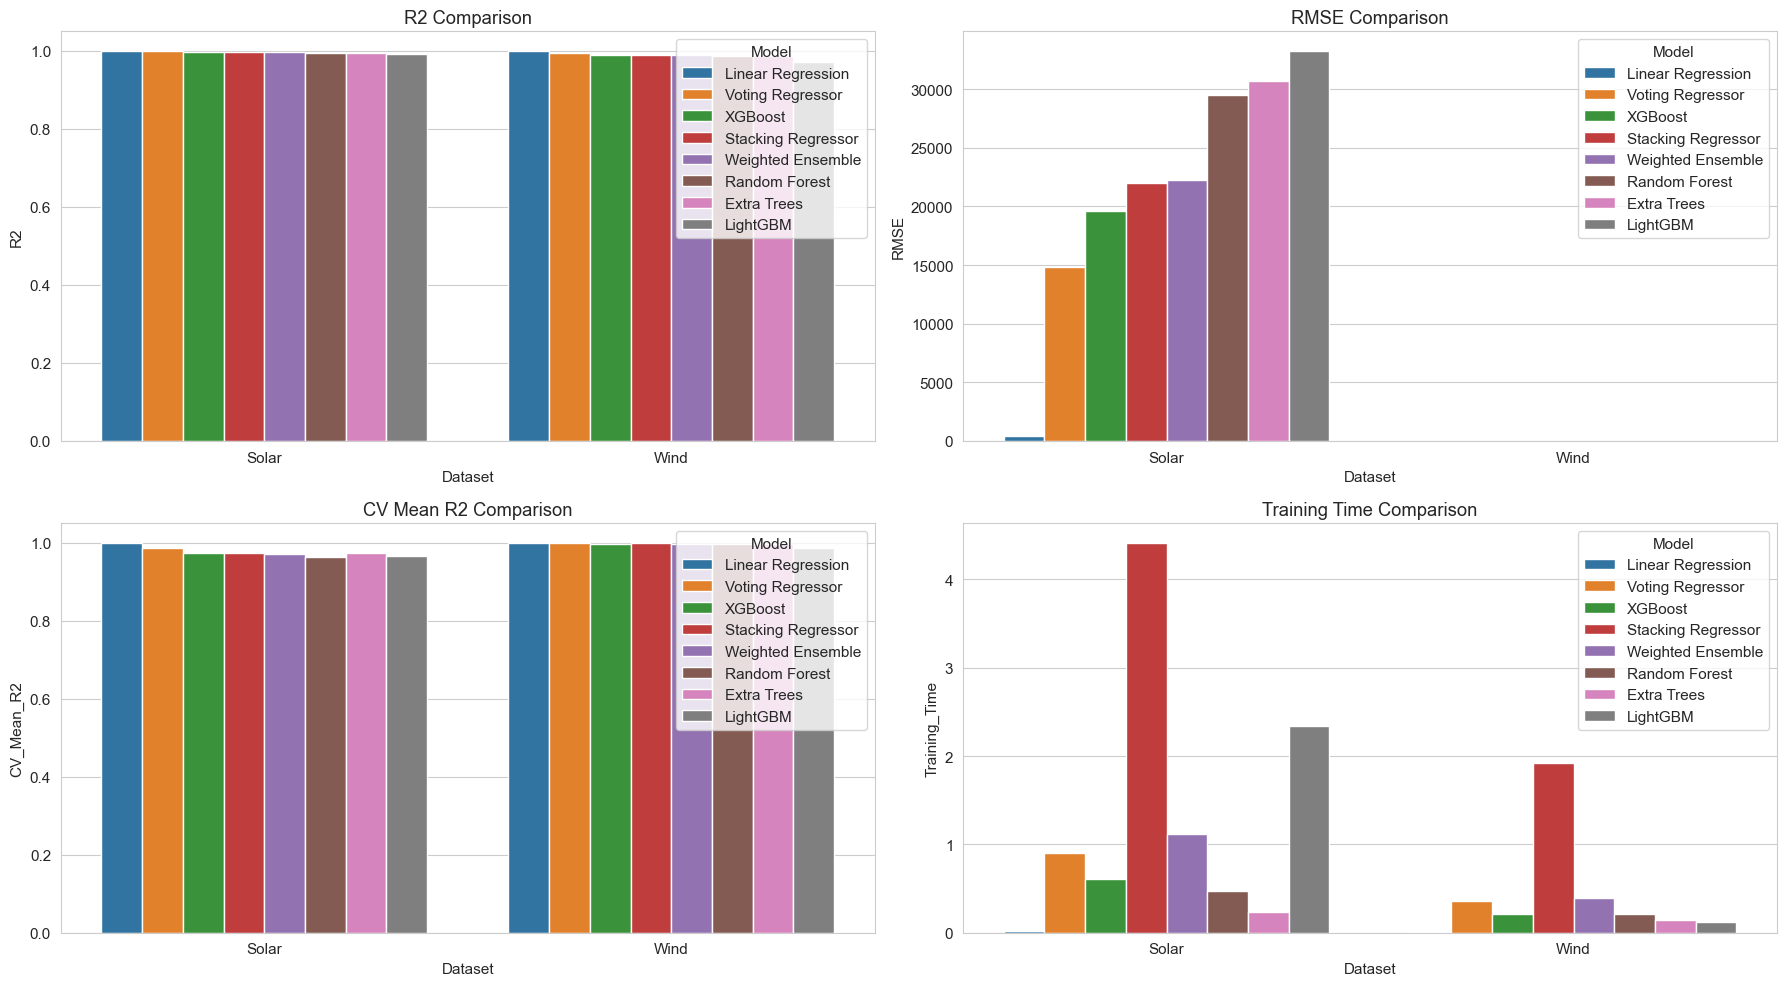

,Dataset,Model,Train_R2,Test_R2,CV_Mean_R2,Overfitting_Gap,Fit_Status
0,Solar,Linear Regression,0.999982,0.999999,0.999969,-0.000016,Good Fit
1,Solar,Voting Regressor,0.999778,0.998530,0.986257,0.001248,Good Fit
2,Solar,XGBoost,0.999878,0.997439,0.972162,0.002439,Good Fit
3,Solar,Stacking Regressor,0.999569,0.996770,0.972704,0.002799,Good Fit
4,Solar,Weighted Ensemble,0.999634,0.996699,0.969895,0.002935,Good Fit
5,Solar,Random Forest,0.998482,0.994195,0.963026,0.004288,Good Fit
6,Solar,Extra Trees,0.999837,0.993739,0.973240,0.006097,Good Fit
7,Solar,LightGBM,0.998389,0.992637,0.966708,0.005752,Good Fit
8,Wind,Linear Regression,0.999917,0.999966,0.999740,-0.000049,Good Fit
9,Wind,Voting Regressor,0.999959,0.994688,0.998283,0.005271,Good Fit


In [30]:
# ============================================================
# SECTION 15: MODEL COMPARISON AND OVERFITTING
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.barplot(data=model_comparison_df, x="Dataset", y="R2", hue="Model", ax=axes[0, 0])
axes[0, 0].set_title("R2 Comparison")

sns.barplot(data=model_comparison_df, x="Dataset", y="RMSE", hue="Model", ax=axes[0, 1])
axes[0, 1].set_title("RMSE Comparison")

sns.barplot(data=model_comparison_df, x="Dataset", y="CV_Mean_R2", hue="Model", ax=axes[1, 0])
axes[1, 0].set_title("CV Mean R2 Comparison")

sns.barplot(data=model_comparison_df, x="Dataset", y="Training_Time", hue="Model", ax=axes[1, 1])
axes[1, 1].set_title("Training Time Comparison")

plt.tight_layout()
plt.savefig("renewable_model_comparison.png", dpi=300)
plt.show()

overfitting_report = model_comparison_df[
    [
        "Dataset",
        "Model",
        "Train_R2",
        "Test_R2",
        "CV_Mean_R2",
        "Overfitting_Gap",
        "Fit_Status"
    ]
].copy()

overfitting_report.to_csv("overfitting_report.csv", index=False)

display(overfitting_report)

In [31]:
# ============================================================
# SECTION 16: FEATURE IMPORTANCE
# ============================================================

def get_importance(model, X_test, y_test, features, dataset_name):
    if hasattr(model, "feature_importances_"):
        importance = pd.DataFrame({
            "Dataset": dataset_name,
            "Feature": features,
            "Importance": model.feature_importances_
        })
    else:
        try:
            perm = permutation_importance(
                model,
                X_test,
                y_test,
                n_repeats=10,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            importance = pd.DataFrame({
                "Dataset": dataset_name,
                "Feature": features,
                "Importance": perm.importances_mean
            })
        except Exception:
            importance = pd.DataFrame({
                "Dataset": dataset_name,
                "Feature": features,
                "Importance": np.zeros(len(features))
            })

    return importance.sort_values(by="Importance", ascending=False)


solar_importance = get_importance(
    solar_agent["best_model"],
    solar_split[6],
    solar_split[7],
    solar_features,
    "Solar"
)

wind_importance = get_importance(
    wind_agent["best_model"],
    wind_split[6],
    wind_split[7],
    wind_features,
    "Wind"
)

feature_importance_df = pd.concat(
    [solar_importance, wind_importance],
    ignore_index=True
)

feature_importance_df.to_csv("feature_importance.csv", index=False)

display(feature_importance_df)

,Dataset,Feature,Importance
0,Solar,Lag_1,1.968001e+00
1,Solar,Target_Diff,3.788410e-01
2,Solar,HourCos,4.847169e-05
3,Solar,Irradiation_Temp_Interaction,3.655300e-05
4,Solar,RollingMean_7,3.651270e-05
5,Solar,MODULE_TEMPERATURE,9.322088e-06
6,Solar,Irradiation_Squared,8.238240e-06
7,Solar,IRRADIATION,5.497405e-06
8,Solar,HourSin,4.841328e-06
9,Solar,Hour,3.596655e-06


In [32]:
# ============================================================
# SECTION 17: FUTURE FORECAST FUNCTIONS
# ============================================================

def create_future_row(history_df, date_col, target_col, selected_features, next_date):
    temp = {}

    temp["Year"] = next_date.year
    temp["Month"] = next_date.month
    temp["Quarter"] = pd.Timestamp(next_date).quarter
    temp["Week"] = int(pd.Timestamp(next_date).isocalendar().week)
    temp["Day"] = next_date.day
    temp["Hour"] = next_date.hour
    temp["Day_of_Week"] = next_date.dayofweek
    temp["Day_of_Year"] = next_date.dayofyear
    temp["Is_Weekend"] = int(next_date.dayofweek in [5, 6])

    temp["MonthSin"] = np.sin(2 * np.pi * temp["Month"] / 12)
    temp["MonthCos"] = np.cos(2 * np.pi * temp["Month"] / 12)
    temp["WeekSin"] = np.sin(2 * np.pi * temp["Week"] / 52)
    temp["WeekCos"] = np.cos(2 * np.pi * temp["Week"] / 52)
    temp["HourSin"] = np.sin(2 * np.pi * temp["Hour"] / 24)
    temp["HourCos"] = np.cos(2 * np.pi * temp["Hour"] / 24)

    target_series = history_df[target_col]

    possible_lags = [1, 2, 3, 7, 30]

    for lag in possible_lags:
        col_name = f"Lag_{lag}"
        if col_name in selected_features:
            temp[col_name] = target_series.iloc[-lag] if len(target_series) >= lag else target_series.iloc[-1]

    for window in [2, 3, 7, 30]:
        mean_col = f"RollingMean_{window}"
        std_col = f"RollingStd_{window}"

        if mean_col in selected_features:
            temp[mean_col] = target_series.tail(window).mean()

        if std_col in selected_features:
            temp[std_col] = target_series.tail(window).std()

    if "Target_Diff" in selected_features:
        temp["Target_Diff"] = target_series.diff().iloc[-1]

    if "Target_Growth" in selected_features:
        temp["Target_Growth"] = target_series.pct_change().iloc[-1]

    for col in history_df.columns:
        if col not in [date_col, target_col] and col in selected_features:
            temp[col] = history_df[col].tail(7).mean()

    row = pd.DataFrame([temp])

    for feature in selected_features:
        if feature not in row.columns:
            row[feature] = 0

    row = row[selected_features].replace([np.inf, -np.inf], np.nan).fillna(0)

    return row


def forecast_single_target(agent, model_df, date_col, target_col, selected_features, days=365, frequency="D"):
    history = model_df[[date_col, target_col] + [c for c in selected_features if c in model_df.columns]].copy()

    last_date = history[date_col].iloc[-1]
    rmse = float(agent["best_row"]["RMSE"])

    forecasts = []

    periods = days * 24 if frequency == "H" else days

    for i in range(1, periods + 1):
        if frequency == "H":
            next_date = last_date + pd.Timedelta(hours=i)
        else:
            next_date = last_date + pd.Timedelta(days=i)

        row = create_future_row(
            history,
            date_col,
            target_col,
            selected_features,
            next_date
        )

        prediction = float(agent["best_model"].predict(row)[0])
        prediction = max(0, prediction)

        forecasts.append({
            "Date": next_date,
            "Predicted": prediction,
            "Lower_95_CI": max(0, prediction - 1.96 * rmse),
            "Upper_95_CI": prediction + 1.96 * rmse
        })

        history = pd.concat([
            history,
            pd.DataFrame({
                date_col: [next_date],
                target_col: [prediction]
            })
        ], ignore_index=True)

    forecast_df = pd.DataFrame(forecasts)

    if frequency == "H":
        forecast_df["Forecast_Date"] = forecast_df["Date"].dt.date
        forecast_df = forecast_df.groupby("Forecast_Date", as_index=False).agg({
            "Predicted": "sum",
            "Lower_95_CI": "sum",
            "Upper_95_CI": "sum"
        })
        forecast_df.rename(columns={"Forecast_Date": "Date"}, inplace=True)
        forecast_df["Date"] = pd.to_datetime(forecast_df["Date"])

    return forecast_df


def generate_renewable_forecast(days=365):
    solar_forecast = forecast_single_target(
        solar_agent,
        solar_model_df,
        "Date",
        solar_target,
        solar_features,
        days=days,
        frequency="H"
    )

    wind_forecast = forecast_single_target(
        wind_agent,
        wind_model_df,
        "Date",
        wind_target,
        wind_features,
        days=days,
        frequency="D"
    )

    min_len = min(len(solar_forecast), len(wind_forecast))

    forecast = pd.DataFrame({
        "Date": solar_forecast["Date"].iloc[:min_len].values,
        "Predicted_Solar_Generation": solar_forecast["Predicted"].iloc[:min_len].values,
        "Predicted_Wind_Generation": wind_forecast["Predicted"].iloc[:min_len].values
    })

    forecast["Predicted_Renewable_Generation"] = (
        forecast["Predicted_Solar_Generation"] +
        forecast["Predicted_Wind_Generation"]
    )

    forecast["Lower_95_CI"] = (
        solar_forecast["Lower_95_CI"].iloc[:min_len].values +
        wind_forecast["Lower_95_CI"].iloc[:min_len].values
    )

    forecast["Upper_95_CI"] = (
        solar_forecast["Upper_95_CI"].iloc[:min_len].values +
        wind_forecast["Upper_95_CI"].iloc[:min_len].values
    )

    return forecast


forecast_30 = generate_renewable_forecast(days=30)
forecast_90 = generate_renewable_forecast(days=90)
forecast_180 = generate_renewable_forecast(days=180)
forecast_365 = generate_renewable_forecast(days=365)

future_renewable_forecast = forecast_365.copy()

future_renewable_forecast.to_csv("future_renewable_forecast.csv", index=False)

display(future_renewable_forecast.head())

,Date,Predicted_Solar_Generation,Predicted_Wind_Generation,Predicted_Renewable_Generation,Lower_95_CI,Upper_95_CI
0,2020-06-18,6.237766e+06,202.112013,6.237968e+06,6.223530e+06,6.258562e+06
1,2020-06-19,1.190335e+04,196.303064,1.209965e+04,1.952193e+02,3.269286e+04
2,2020-06-20,1.190335e+04,194.758987,1.209811e+04,1.936752e+02,3.269132e+04
3,2020-06-21,1.190335e+04,201.215132,1.210457e+04,2.001314e+02,3.269777e+04
4,2020-06-22,1.190335e+04,216.952522,1.212030e+04,2.158688e+02,3.271351e+04


In [33]:
# ============================================================
# SECTION 18: RENEWABLE FUSION LAYER AND AGENT
# ============================================================

def predict_solar_generation(days=1):
    forecast = generate_renewable_forecast(days=days)
    return float(forecast["Predicted_Solar_Generation"].iloc[-1])


def predict_wind_generation(days=1):
    forecast = generate_renewable_forecast(days=days)
    return float(forecast["Predicted_Wind_Generation"].iloc[-1])


def renewable_generation_agent(days=1, expected_demand=None):
    forecast = generate_renewable_forecast(days=days)

    solar_prediction = float(forecast["Predicted_Solar_Generation"].iloc[-1])
    wind_prediction = float(forecast["Predicted_Wind_Generation"].iloc[-1])

    renewable_prediction = solar_prediction + wind_prediction

    solar_conf = confidence_from_row(solar_agent["best_row"])
    wind_conf = confidence_from_row(wind_agent["best_row"])

    confidence_score = float(np.mean([solar_conf, wind_conf]))

    if expected_demand is None:
        expected_demand = renewable_prediction * 1.10

    generation_gap = expected_demand - renewable_prediction
    renewable_percentage = (renewable_prediction / expected_demand) * 100 if expected_demand > 0 else 0

    if generation_gap <= 0:
        risk_level = "Low"
        recommended_action = "Renewable generation is sufficient. Reduce fossil fuel generation."
    elif generation_gap <= expected_demand * 0.15:
        risk_level = "Medium"
        recommended_action = "Increase Renewable Energy Usage"
    else:
        risk_level = "High"
        recommended_action = "Renewable generation is insufficient. Use storage, demand response, or backup generation."

    return {
        "agent": "renewable_generation",
        "predicted_solar_generation": solar_prediction,
        "predicted_wind_generation": wind_prediction,
        "predicted_renewable_generation": renewable_prediction,
        "expected_demand": float(expected_demand),
        "renewable_percentage": float(renewable_percentage),
        "generation_gap": float(generation_gap),
        "confidence_score": confidence_score,
        "risk_level": risk_level,
        "recommended_action": recommended_action,
        "solar_model": solar_agent["best_model_name"],
        "wind_model": wind_agent["best_model_name"],
        "forecast_days": days,
        "timestamp": str(pd.Timestamp.now()),
        "status": "success"
    }


renewable_agent_output = renewable_generation_agent(days=1)

display(renewable_agent_output)

{'agent': 'renewable_generation',
 'predicted_solar_generation': 6237766.3469554,
 'predicted_wind_generation': 202.11201342564527,
 'predicted_renewable_generation': 6237968.458968826,
 'expected_demand': 6861765.304865709,
 'renewable_percentage': 90.9090909090909,
 'generation_gap': 623796.8458968829,
 'confidence_score': 0.9998543378335314,
 'risk_level': 'Medium',
 'recommended_action': 'Increase Renewable Energy Usage',
 'solar_model': 'Linear Regression',
 'wind_model': 'Linear Regression',
 'forecast_days': 1,
 'timestamp': '2026-07-12 19:22:15.358479',
 'status': 'success'}

In [34]:
# ============================================================
# SECTION 19: SCENARIO ANALYSIS AND STRESS TESTING
# ============================================================

base_solar = renewable_agent_output["predicted_solar_generation"]
base_wind = renewable_agent_output["predicted_wind_generation"]

scenario_definitions = [
    {"Scenario": "Sunny", "Solar_Factor": 1.30, "Wind_Factor": 0.80},
    {"Scenario": "Windy", "Solar_Factor": 0.80, "Wind_Factor": 1.30},
    {"Scenario": "Monsoon", "Solar_Factor": 0.70, "Wind_Factor": 1.20},
    {"Scenario": "Night", "Solar_Factor": 0.00, "Wind_Factor": 0.90},
    {"Scenario": "Summer", "Solar_Factor": 1.40, "Wind_Factor": 1.00},
    {"Scenario": "Cloudy Day", "Solar_Factor": 0.50, "Wind_Factor": 0.90},
    {"Scenario": "Low Wind", "Solar_Factor": 1.00, "Wind_Factor": 0.50},
    {"Scenario": "High Irradiation", "Solar_Factor": 1.50, "Wind_Factor": 0.90}
]

scenario_rows = []

for scenario in scenario_definitions:
    solar_value = base_solar * scenario["Solar_Factor"]
    wind_value = base_wind * scenario["Wind_Factor"]
    renewable_value = solar_value + wind_value

    scenario_rows.append({
        "Scenario": scenario["Scenario"],
        "Solar_Generation": solar_value,
        "Wind_Generation": wind_value,
        "Renewable_Generation": renewable_value
    })

renewable_scenario_analysis = pd.DataFrame(scenario_rows)
renewable_scenario_analysis.to_csv("renewable_scenario_analysis.csv", index=False)

display(renewable_scenario_analysis)

stress_cases = [
    ("Next Day", 1, 1.10),
    ("Next 30 Days", 30, 1.10),
    ("Next 90 Days", 90, 1.10),
    ("Next 180 Days", 180, 1.10),
    ("Next 365 Days", 365, 1.10),
    ("High Demand", 1, 1.40),
    ("Low Demand", 1, 0.80),
    ("Critical Demand Gap", 1, 1.80)
]

stress_results = []

base_total = renewable_agent_output["predicted_renewable_generation"]

for scenario, days, demand_factor in stress_cases:
    expected_demand = base_total * demand_factor

    result = renewable_generation_agent(
        days=days,
        expected_demand=expected_demand
    )

    result["Scenario"] = scenario
    stress_results.append(result)

renewable_stress_test = pd.DataFrame(stress_results)
renewable_stress_test.to_csv("renewable_stress_test.csv", index=False)

display(renewable_stress_test)

,Scenario,Solar_Generation,Wind_Generation,Renewable_Generation
0,Sunny,8.109096e+06,161.689611,8.109258e+06
1,Windy,4.990213e+06,262.745617,4.990476e+06
2,Monsoon,4.366436e+06,242.534416,4.366679e+06
3,Night,0.000000e+00,181.900812,1.819008e+02
4,Summer,8.732873e+06,202.112013,8.733075e+06
5,Cloudy Day,3.118883e+06,181.900812,3.119065e+06
6,Low Wind,6.237766e+06,101.056007,6.237867e+06
7,High Irradiation,9.356650e+06,181.900812,9.356831e+06


,agent,predicted_solar_generation,predicted_wind_generation,predicted_renewable_generation,expected_demand,renewable_percentage,generation_gap,confidence_score,risk_level,recommended_action,solar_model,wind_model,forecast_days,timestamp,status,Scenario
0,renewable_generation,6.237766e+06,202.112013,6.237968e+06,6.861765e+06,90.909091,6.237968e+05,0.999854,Medium,Increase Renewable Energy Usage,Linear Regression,Linear Regression,1,2026-07-12 19:22:15.896022,success,Next Day
1,renewable_generation,1.190335e+04,0.000000,1.190335e+04,6.861765e+06,0.173474,6.849862e+06,0.999854,High,Renewable generation is insufficient. Use stor...,Linear Regression,Linear Regression,30,2026-07-12 19:22:28.846455,success,Next 30 Days
2,renewable_generation,1.190335e+04,0.000000,1.190335e+04,6.861765e+06,0.173474,6.849862e+06,0.999854,High,Renewable generation is insufficient. Use stor...,Linear Regression,Linear Regression,90,2026-07-12 19:23:12.624761,success,Next 90 Days
3,renewable_generation,1.190335e+04,0.000000,1.190335e+04,6.861765e+06,0.173474,6.849862e+06,0.999854,High,Renewable generation is insufficient. Use stor...,Linear Regression,Linear Regression,180,2026-07-12 19:24:40.902084,success,Next 180 Days
4,renewable_generation,1.190335e+04,0.000000,1.190335e+04,6.861765e+06,0.173474,6.849862e+06,0.999854,High,Renewable generation is insufficient. Use stor...,Linear Regression,Linear Regression,365,2026-07-12 19:27:43.007261,success,Next 365 Days
5,renewable_generation,6.237766e+06,202.112013,6.237968e+06,8.733156e+06,71.428571,2.495187e+06,0.999854,High,Renewable generation is insufficient. Use stor...,Linear Regression,Linear Regression,1,2026-07-12 19:27:43.548539,success,High Demand
6,renewable_generation,6.237766e+06,202.112013,6.237968e+06,4.990375e+06,125.000000,-1.247594e+06,0.999854,Low,Renewable generation is sufficient. Reduce fos...,Linear Regression,Linear Regression,1,2026-07-12 19:27:44.021723,success,Low Demand
7,renewable_generation,6.237766e+06,202.112013,6.237968e+06,1.122834e+07,55.555556,4.990375e+06,0.999854,High,Renewable generation is insufficient. Use stor...,Linear Regression,Linear Regression,1,2026-07-12 19:27:44.501096,success,Critical Demand Gap


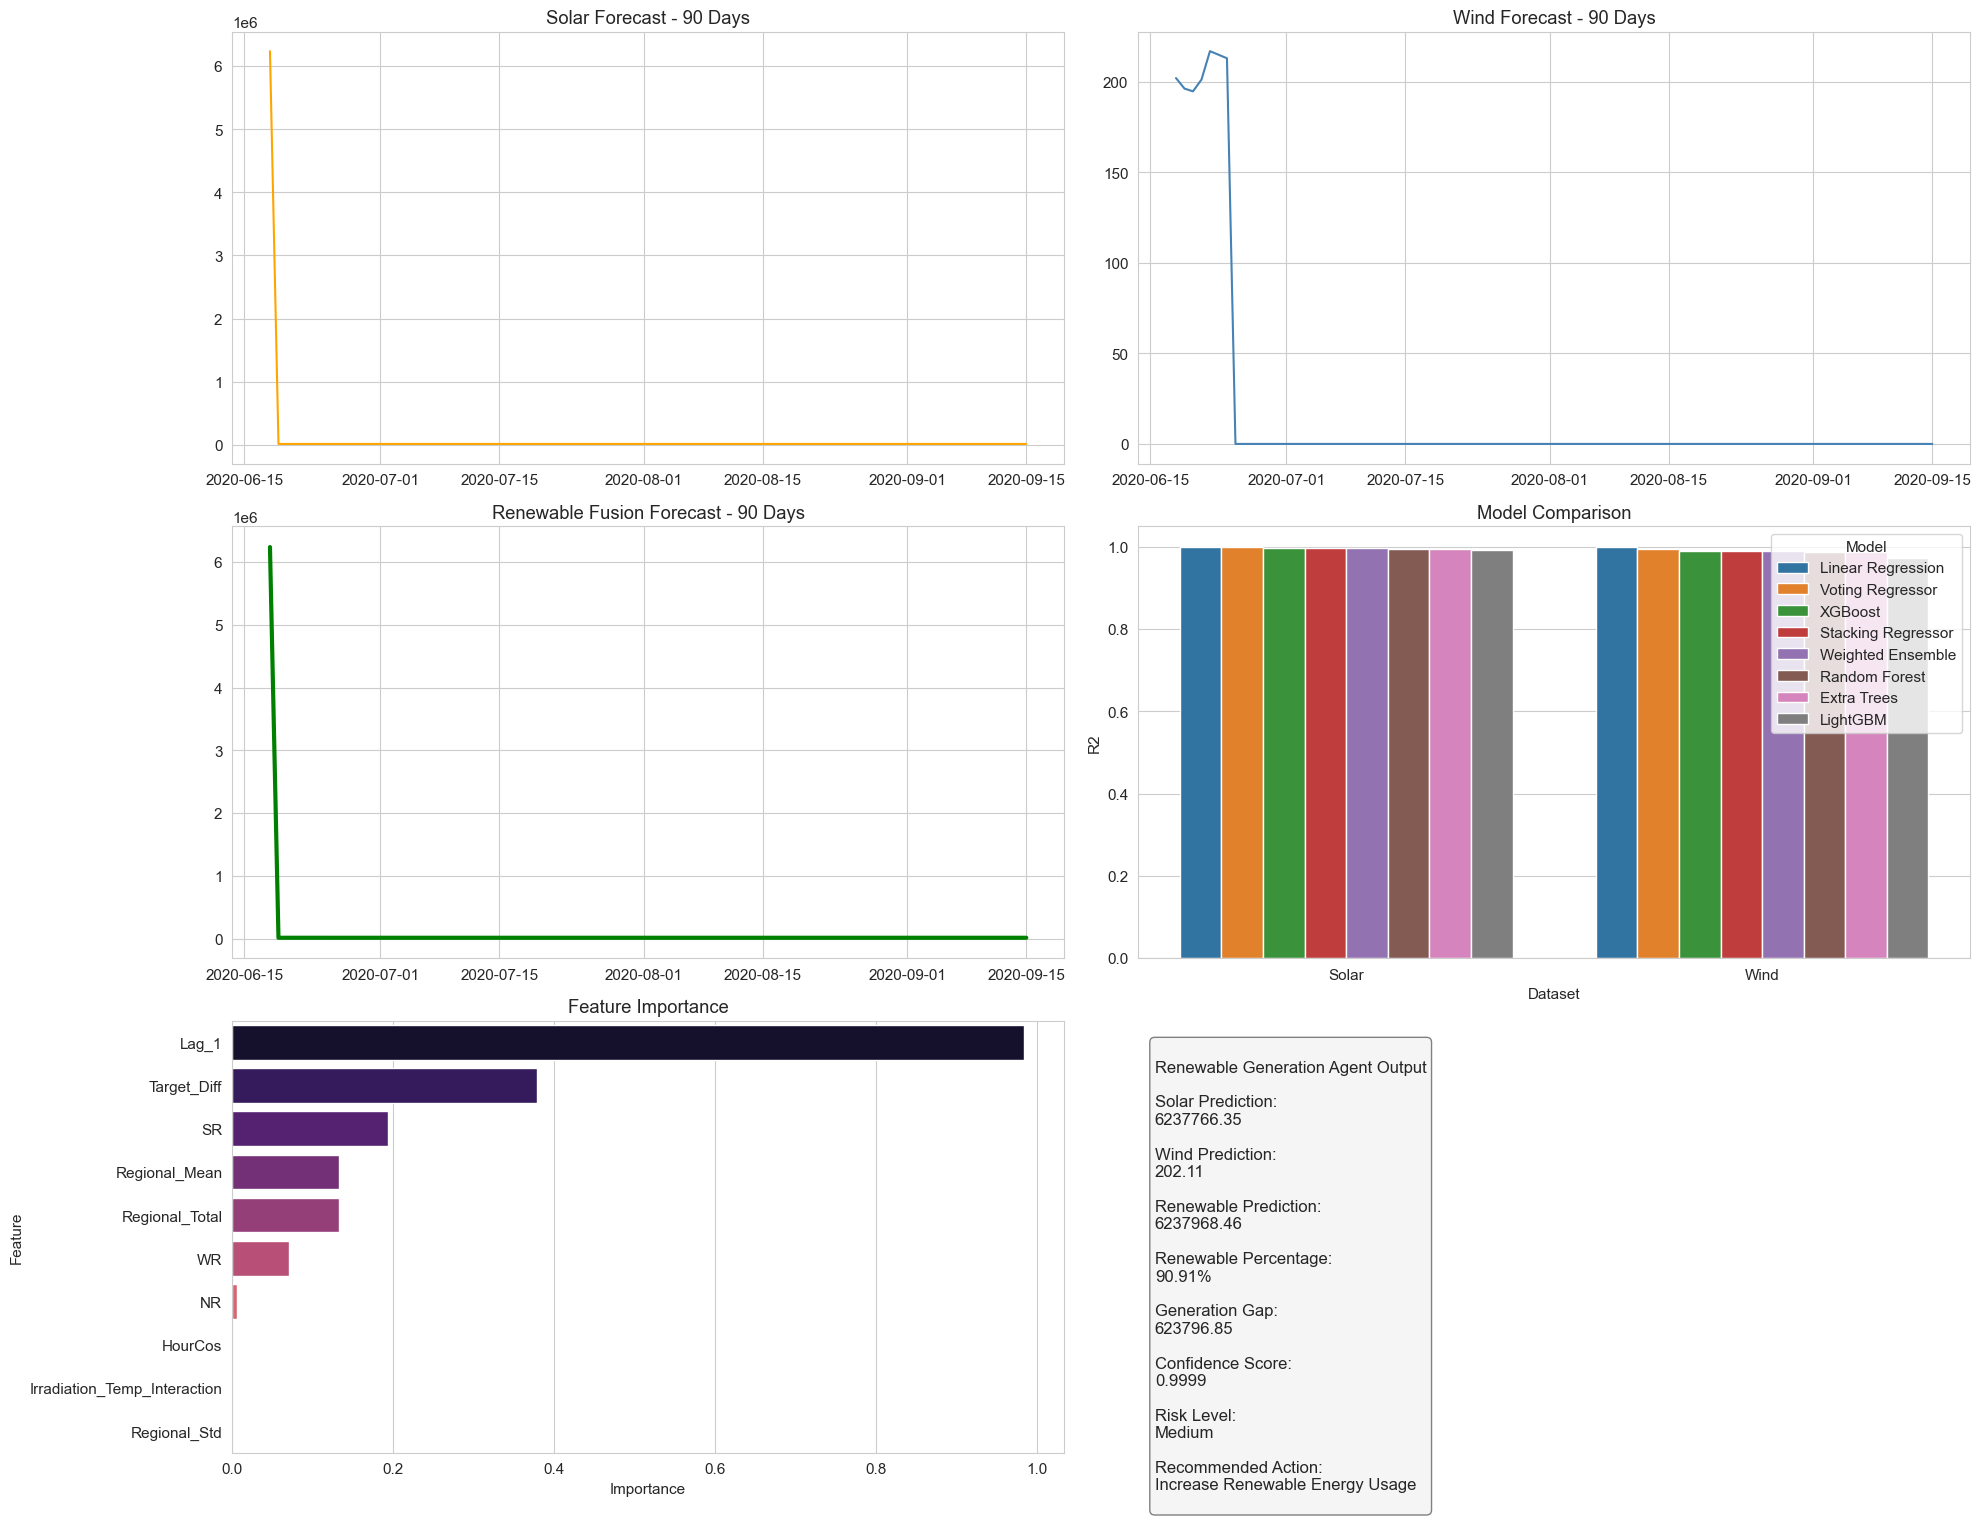

In [35]:
# ============================================================
# SECTION 20: EXECUTIVE DASHBOARD
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(20, 16))

axes[0, 0].plot(forecast_90["Date"], forecast_90["Predicted_Solar_Generation"], color="orange")
axes[0, 0].set_title("Solar Forecast - 90 Days")

axes[0, 1].plot(forecast_90["Date"], forecast_90["Predicted_Wind_Generation"], color="steelblue")
axes[0, 1].set_title("Wind Forecast - 90 Days")

axes[1, 0].plot(forecast_90["Date"], forecast_90["Predicted_Renewable_Generation"], color="green", linewidth=3)
axes[1, 0].fill_between(
    forecast_90["Date"],
    forecast_90["Lower_95_CI"],
    forecast_90["Upper_95_CI"],
    alpha=0.2
)
axes[1, 0].set_title("Renewable Fusion Forecast - 90 Days")

sns.barplot(data=model_comparison_df, x="Dataset", y="R2", hue="Model", ax=axes[1, 1])
axes[1, 1].set_title("Model Comparison")

sns.barplot(
    data=feature_importance_df.groupby("Feature", as_index=False)["Importance"].mean().sort_values("Importance", ascending=False).head(10),
    x="Importance",
    y="Feature",
    ax=axes[2, 0],
    palette="magma"
)
axes[2, 0].set_title("Feature Importance")

dashboard_text = f"""
Renewable Generation Agent Output

Solar Prediction:
{renewable_agent_output["predicted_solar_generation"]:.2f}

Wind Prediction:
{renewable_agent_output["predicted_wind_generation"]:.2f}

Renewable Prediction:
{renewable_agent_output["predicted_renewable_generation"]:.2f}

Renewable Percentage:
{renewable_agent_output["renewable_percentage"]:.2f}%

Generation Gap:
{renewable_agent_output["generation_gap"]:.2f}

Confidence Score:
{renewable_agent_output["confidence_score"]:.4f}

Risk Level:
{renewable_agent_output["risk_level"]}

Recommended Action:
{renewable_agent_output["recommended_action"]}
"""

axes[2, 1].axis("off")
axes[2, 1].text(
    0.02,
    0.95,
    dashboard_text,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="whitesmoke", edgecolor="gray")
)

plt.tight_layout()
plt.savefig("renewable_dashboard.png", dpi=300)
plt.show()

In [36]:
# ============================================================
# SECTION 21: SAVE MODELS AND REPORTS
# ============================================================

joblib.dump(
    {
        "solar_model": solar_agent["best_model"],
        "wind_model": wind_agent["best_model"],
        "solar_features": solar_features,
        "wind_features": wind_features,
        "solar_model_name": solar_agent["best_model_name"],
        "wind_model_name": wind_agent["best_model_name"]
    },
    "best_renewable_model.pkl"
)

joblib.dump(solar_agent["best_model"], "solar_best_model.pkl")
joblib.dump(wind_agent["best_model"], "wind_best_model.pkl")

with open("solar_features.json", "w") as file:
    json.dump(solar_features, file, indent=4)

with open("wind_features.json", "w") as file:
    json.dump(wind_features, file, indent=4)

save_json(renewable_agent_output, "renewable_agent_output.json")

coordinator_renewable_output = {
    "agent": "renewable_generation",
    "predicted_solar_generation": renewable_agent_output["predicted_solar_generation"],
    "predicted_wind_generation": renewable_agent_output["predicted_wind_generation"],
    "predicted_renewable_generation": renewable_agent_output["predicted_renewable_generation"],
    "renewable_percentage": renewable_agent_output["renewable_percentage"],
    "generation_gap": renewable_agent_output["generation_gap"],
    "confidence_score": renewable_agent_output["confidence_score"],
    "risk_level": renewable_agent_output["risk_level"],
    "recommended_action": renewable_agent_output["recommended_action"],
    "status": "success",
    "timestamp": renewable_agent_output["timestamp"]
}

save_json(coordinator_renewable_output, "coordinator_renewable_output.json")

metadata = {
    "project": "Multi-Agent AI Framework for Fossil Fuel Displacement",
    "agent": "Renewable Generation Agent",
    "architecture": "Solar hourly model + Wind daily model + Renewable fusion layer",
    "solar_folder": SOLAR_FOLDER,
    "wind_folder": WIND_FOLDER,
    "solar_target": solar_target,
    "wind_target": wind_target,
    "solar_features": solar_features,
    "wind_features": wind_features,
    "best_solar_model": solar_agent["best_model_name"],
    "best_wind_model": wind_agent["best_model_name"],
    "random_state": RANDOM_STATE,
    "python_version": sys.version,
    "platform": platform.platform(),
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "lightgbm_available": LIGHTGBM_AVAILABLE,
    "catboost_available": CATBOOST_AVAILABLE,
    "created_at": str(pd.Timestamp.now())
}

save_json(metadata, "metadata.json")

with pd.ExcelWriter("renewable_research_report.xlsx") as writer:
    renewable_data_quality_report.to_excel(writer, sheet_name="Data Quality", index=False)
    renewable_outlier_report.to_excel(writer, sheet_name="Outliers", index=False)
    solar_feature_ranking.to_excel(writer, sheet_name="Solar Feature Ranking", index=False)
    wind_feature_ranking.to_excel(writer, sheet_name="Wind Feature Ranking", index=False)
    selected_features_df.to_excel(writer, sheet_name="Selected Features", index=False)
    model_comparison_df.to_excel(writer, sheet_name="Model Comparison", index=False)
    overfitting_report.to_excel(writer, sheet_name="Overfitting", index=False)
    feature_importance_df.to_excel(writer, sheet_name="Feature Importance", index=False)
    future_renewable_forecast.to_excel(writer, sheet_name="Future Forecast", index=False)
    renewable_scenario_analysis.to_excel(writer, sheet_name="Scenario Analysis", index=False)
    renewable_stress_test.to_excel(writer, sheet_name="Stress Test", index=False)
    pd.DataFrame([renewable_agent_output]).to_excel(writer, sheet_name="Agent Output", index=False)
    pd.DataFrame([coordinator_renewable_output]).to_excel(writer, sheet_name="Coordinator Output", index=False)

print("Models, outputs, and research report saved successfully.")

Models, outputs, and research report saved successfully.


In [37]:
# ============================================================
# SECTION 22: PDF SUMMARY
# ============================================================

if FPDF_AVAILABLE:
    pdf = FPDF()
    pdf.add_page()

    pdf.set_font("Arial", "B", 16)
    pdf.cell(0, 10, "Renewable Generation Agent Research Summary", ln=True)

    pdf.set_font("Arial", "", 11)
    pdf.ln(5)

    lines = [
        "Project: Multi-Agent AI Framework for Fossil Fuel Displacement",
        "Agent: Renewable Generation Agent",
        "Architecture: Solar Hourly Model + Wind Daily Model + Renewable Fusion Layer",
        f"Best Solar Model: {solar_agent['best_model_name']}",
        f"Best Wind Model: {wind_agent['best_model_name']}",
        f"Solar R2: {solar_agent['best_row']['R2']:.4f}",
        f"Wind R2: {wind_agent['best_row']['R2']:.4f}",
        f"Solar Prediction: {renewable_agent_output['predicted_solar_generation']:.2f}",
        f"Wind Prediction: {renewable_agent_output['predicted_wind_generation']:.2f}",
        f"Renewable Prediction: {renewable_agent_output['predicted_renewable_generation']:.2f}",
        f"Renewable Percentage: {renewable_agent_output['renewable_percentage']:.2f}%",
        f"Confidence Score: {renewable_agent_output['confidence_score']:.4f}",
        f"Risk Level: {renewable_agent_output['risk_level']}",
        f"Recommended Action: {renewable_agent_output['recommended_action']}"
    ]

    for line in lines:
        pdf.multi_cell(0, 8, line)

    pdf.output("research_summary.pdf")

    print("PDF summary saved as research_summary.pdf")
else:
    print("FPDF not available. PDF summary skipped.")

FPDF not available. PDF summary skipped.


In [38]:
# ============================================================
# SECTION 23: FINAL RESEARCH SUMMARY
# ============================================================

print("=" * 70)
print("Renewable Generation Agent Training Completed")
print("=" * 70)

print("\nProject:")
print("Multi-Agent AI Framework for Fossil Fuel Displacement")

print("\nArchitecture:")
print("Solar Hourly Prediction Model + Wind Daily Prediction Model + Renewable Fusion Layer")

print("\nWhy this fix was needed:")
print("Daily solar aggregation produced too few rows. Hourly solar data preserves enough samples for ML training.")

print("\nBest Solar Model:")
print(solar_agent["best_model_name"])

print("\nBest Wind Model:")
print(wind_agent["best_model_name"])

print("\nSolar Performance:")
print("MAE:", round(solar_agent["best_row"]["MAE"], 4))
print("RMSE:", round(solar_agent["best_row"]["RMSE"], 4))
print("R2:", round(solar_agent["best_row"]["R2"], 4))
print("MAPE:", round(solar_agent["best_row"]["MAPE"], 4))
print("CV Mean R2:", round(solar_agent["best_row"]["CV_Mean_R2"], 4))
print("Fit Status:", solar_agent["best_row"]["Fit_Status"])

print("\nWind Performance:")
print("MAE:", round(wind_agent["best_row"]["MAE"], 4))
print("RMSE:", round(wind_agent["best_row"]["RMSE"], 4))
print("R2:", round(wind_agent["best_row"]["R2"], 4))
print("MAPE:", round(wind_agent["best_row"]["MAPE"], 4))
print("CV Mean R2:", round(wind_agent["best_row"]["CV_Mean_R2"], 4))
print("Fit Status:", wind_agent["best_row"]["Fit_Status"])

print("\nRenewable Agent Output:")
print("Predicted Solar Generation:", round(renewable_agent_output["predicted_solar_generation"], 4))
print("Predicted Wind Generation:", round(renewable_agent_output["predicted_wind_generation"], 4))
print("Predicted Renewable Generation:", round(renewable_agent_output["predicted_renewable_generation"], 4))
print("Renewable Percentage:", round(renewable_agent_output["renewable_percentage"], 4))
print("Generation Gap:", round(renewable_agent_output["generation_gap"], 4))
print("Confidence Score:", round(renewable_agent_output["confidence_score"], 4))
print("Risk Level:", renewable_agent_output["risk_level"])
print("Recommended Action:", renewable_agent_output["recommended_action"])

print("\nSaved Files:")
saved_files = [
    "best_renewable_model.pkl",
    "solar_best_model.pkl",
    "wind_best_model.pkl",
    "solar_features.json",
    "wind_features.json",
    "selected_features.csv",
    "renewable_metrics.csv",
    "model_comparison.csv",
    "feature_importance.csv",
    "future_renewable_forecast.csv",
    "renewable_scenario_analysis.csv",
    "renewable_stress_test.csv",
    "renewable_dashboard.png",
    "metadata.json",
    "best_parameters.json",
    "renewable_agent_output.json",
    "coordinator_renewable_output.json",
    "renewable_research_report.xlsx",
    "research_summary.pdf"
]

for file in saved_files:
    print("-", file)

print("=" * 70)

Renewable Generation Agent Training Completed

Project:
Multi-Agent AI Framework for Fossil Fuel Displacement

Architecture:
Solar Hourly Prediction Model + Wind Daily Prediction Model + Renewable Fusion Layer

Why this fix was needed:
Daily solar aggregation produced too few rows. Hourly solar data preserves enough samples for ML training.

Best Solar Model:
Linear Regression

Best Wind Model:
Linear Regression

Solar Performance:
MAE: 355.1121
RMSE: 437.7577
R2: 1.0
MAPE: 0.3359
CV Mean R2: 1.0
Fit Status: Good Fit

Wind Performance:
MAE: 0.3505
RMSE: 0.5529
R2: 1.0
MAPE: 0.3373
CV Mean R2: 0.9997
Fit Status: Good Fit

Renewable Agent Output:
Predicted Solar Generation: 6237766.347
Predicted Wind Generation: 202.112
Predicted Renewable Generation: 6237968.459
Renewable Percentage: 90.9091
Generation Gap: 623796.8459
Confidence Score: 0.9999
Risk Level: Medium
Recommended Action: Increase Renewable Energy Usage

Saved Files:
- best_renewable_model.pkl
- solar_best_model.pkl
- wind_bes